To design and train an autoencoder model for image noise reduction by implementating

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D, BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [21]:
# using mnist dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

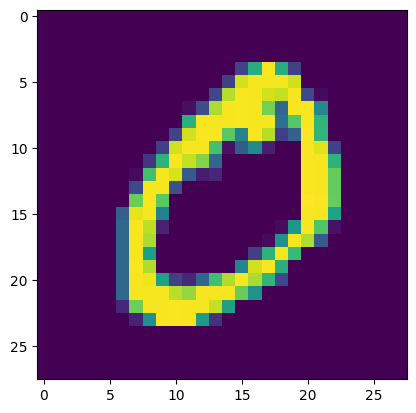

In [22]:
plt.imshow(X_train[1].reshape(28,28))

In [23]:
# applying noralization : pixeal value range from 0-255. normalize them btw 0 and 1

X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

In [24]:
# reshape dataset for cnn

X_train = np.reshape(X_train, (len(X_train), 28,28, 1))
X_test = np.reshape(X_test, (len(X_test), 28,28, 1))
print(X_train.shape)

(60000, 28, 28, 1)


In [28]:
# Add noise to image

noise_factor = 0.5
X_train_noise = X_train + noise_factor * np.random.normal(loc=0.0,
                                                          scale=1.0,
                                                          size = X_train.shape)

X_test_noise = X_test + noise_factor * np.random.normal(loc=0.0,
                                                         scale=1.0,
                                                         size = X_test.shape)

In [30]:
X_train_noise = np.clip(X_train_noise, 0., 1.)
X_test_noise = np.clip(X_test_noise, 0., 1.)

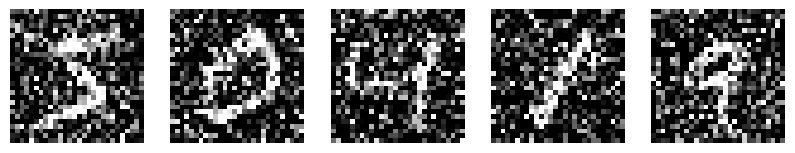

In [38]:
plt.figure(figsize=(10,2))

for i in range(5):
  ax = plt.subplot(1,5,i+1)
  plt.imshow(X_train_noise[i].reshape(28,28), cmap='gray')
  plt.axis('off')
plt.show()

In [39]:
# encoder decoder architecture

input_img = Input(shape=(28,28,1))
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
encoded = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(64,(3,3), activation='relu', padding='same')(encoded)
x = BatchNormalization()(x)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# create model
autoencoder = Model(input_img, decoded)

In [40]:
autoencoder.compile(optimizer=Adam(),
                    loss = 'binary_crossentropy',
                    metrics=['accuracy'])

In [41]:
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,265 (294.00 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
history = autoencoder.fit(X_train_noise,
                          X_train,
                          epochs=5,
                          batch_size=128,
                          shuffle=True)

In [ ]:
decoder_imgs = autoencoder.predict(x_test_noise)

In [ ]:
n = 5
plt.figure(figsize=(15,5))
for i in range (n):
  ax = plt.subplot(3,n, i+1)
  plt.imshow(X_test[i].reshape(28,28), cmap='gray')
  plt.title('Original')
  plt.axis('off')
  ax = plt.subplot(3,n, i+1)
  plt.imshow(X_test_noise[i].reshape(28,28), cmap='gray')
  plt.title('noise')
  plt.axis('off')
  ax = plt.subplot(3,n, i+1)
  plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
  plt.title('noise')
  plt.axis('off')
plt.show()